In [4]:
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.prompts import PromptTemplate
from langchain.schema.runnable import RunnableSequence
from gtts import gTTS
from langchain.text_splitter import RecursiveCharacterTextSplitter
import json
from huggingface_hub import InferenceClient
import matplotlib.pyplot as plt
load_dotenv()

True

In [5]:
llm = ChatGoogleGenerativeAI(model='gemini-1.5-flash')


In [7]:
story_prompt = PromptTemplate(
    template="""
    You are a creative storyteller.
    Write a detailed, simple to understand, engaging short story based on this idea:
    "{idea}"

    Make sure the story has:
    - easy to understand vocabulary
    - a clear beginning, middle, and end
    - interesting characters
    - vivid but simple descriptions suitable for children
    - emotional depth
    """
    ,input_variables=['idea']
)

In [8]:
story_chain = story_prompt|llm


In [9]:

user_idea = "story of a dog and pigeon"
story = story_chain.invoke({"idea":user_idea})
print("\n--- Your Story ---\n")
print(story.content)


--- Your Story ---

Barnaby the beagle had a nose for trouble, a tail that wagged like a metronome gone wild, and a heart as big as a watermelon.  He lived in a cozy little house with a big, green yard, perfect for sniffing interesting smells and chasing butterflies.  One day, Barnaby discovered a new smell – a strange, feathery smell – coming from the old oak tree.  Peeking under a low-hanging branch, he saw her:  Pip, a pigeon with feathers the color of a summer sky.

Pip was different from the other pigeons.  While they cooed and strutted about, Pip was quiet and alone, her wing slightly bent.  Barnaby, usually a boisterous dog, felt a pang of sympathy.  He whimpered softly, nudging a fallen acorn towards her with his nose.

Pip, startled, looked up at Barnaby with big, dark eyes.  She didn't run.  Instead, she pecked gently at the acorn, then looked at Barnaby again. It was the start of an unusual friendship.

Every day, Barnaby would visit Pip under the oak tree. He'd bring her t

In [10]:
story.content =  """Barnaby the Beagle, a bouncy ball of fur, loved to chase butterflies. Mittens, a sleek black cat with emerald eyes, preferred sunbeams and naps. They were the unlikeliest of friends, living in the same cozy house, but usually keeping to themselves.

One sunny afternoon, Barnaby spotted a particularly magnificent monarch butterfly fluttering near the rose bushes. He barked excitedly, his tail a blur, and took off in hot pursuit. The butterfly led him on a merry chase, right into a thorny thicket! Barnaby yelped, tangled and stuck.

Hearing Barnaby's cries, Mittens, usually aloof, sprang into action. With surprising agility, she weaved through the branches, her sleek body navigating the thorns with ease. She reached Barnaby, gently nudging his head with her nose, and helped him untangle himself.

Free at last, Barnaby licked Mittens's face gratefully. Mittens, purring softly, rubbed against his head. From that day on, their unlikely friendship blossomed. They still enjoyed their separate activities, but they also learned to appreciate each other's company, a sunbeam shared, a chase enjoyed together. They were the best of friends, a dog and a cat, proving that even opposites can find happiness together."""

tts = gTTS(story.content)
audio_file = "audio_file.mp3"
tts.save(audio_file)

In [11]:
consistancy_prompt = PromptTemplate(
    template="""
You are an assistant helping to create a consistent picture book.

Task: From the following story text, extract a structured "visual memory" 
with these fields:
- characters: list with names and physical descriptions
- setting: location/environment details
- objects: important props or items
- style: artistic style or mood if mentioned else go with something that will go nice with story    

Output JSON only starting and ending in curly brackets.

story text:{text}
""",input_variables=["text"]
)

In [12]:
consistancy_chain = consistancy_prompt|llm
visual_memory = consistancy_chain.invoke({"text":story.content})
print(str(visual_memory.content))

{
  "characters": [
    {
      "name": "Barnaby",
      "description": "A bouncy ball of fur Beagle"
    },
    {
      "name": "Mittens",
      "description": "A sleek black cat with emerald eyes"
    }
  ],
  "setting": {
    "location": "A cozy house with a garden containing rose bushes and a thorny thicket",
    "environment": "Sunny afternoon"
  },
  "objects": [
    "Butterflies (Monarch butterfly)",
    "Rose bushes",
    "Thorny thicket"
  ],
  "style": "Warm and inviting, possibly watercolor or gouache with soft lines and bright colors to emphasize the friendly nature of the story and the sunny setting.  Could incorporate some slightly more detailed linework for the thorns to show contrast."
}


In [13]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size=150,chunk_overlap=20,separators=["\n\n", ".", "!", "?", ",", " "])

chunks = text_splitter.split_text(story.content)

In [14]:
list_of_chunks = []
for c in chunks:
    list_of_chunks.append(c)
    print(c+"\n\n")

Barnaby the Beagle, a bouncy ball of fur, loved to chase butterflies. Mittens, a sleek black cat with emerald eyes, preferred sunbeams and naps


. They were the unlikeliest of friends, living in the same cozy house, but usually keeping to themselves.


One sunny afternoon, Barnaby spotted a particularly magnificent monarch butterfly fluttering near the rose bushes


. He barked excitedly, his tail a blur, and took off in hot pursuit


. The butterfly led him on a merry chase, right into a thorny thicket! Barnaby yelped, tangled and stuck.


Hearing Barnaby's cries, Mittens, usually aloof, sprang into action


. With surprising agility, she weaved through the branches, her sleek body navigating the thorns with ease


. She reached Barnaby, gently nudging his head with her nose, and helped him untangle himself.


Free at last, Barnaby licked Mittens's face gratefully. Mittens, purring softly, rubbed against his head


. From that day on, their unlikely friendship blossomed


. They stil

In [15]:
def make_image_prompt(extracted_info, chunk_text):
    """
    Build a high-quality image generation prompt from story chunk + extracted info.
    Ensures descriptive clarity, consistency, and alignment with narrative tone.
    """
    characters = "\n".join(
        [f"- {c['name']}: {c['description']}" for c in extracted_info.get("characters", [])]
    ) or "None specified"
    setting = extracted_info.get("setting", "Unspecified setting")
    objects = ", ".join(extracted_info.get("objects", [])) or "No specific objects"
    style = extracted_info.get("style", "Illustrated storybook style")

    prompt = f"""
    Generate a single detailed illustration for the following story scene. 
    The image should capture the atmosphere, characters, and setting in a visually cohesive way. 

    --- Story Excerpt ---
    "{chunk_text}"

    --- Characters ---
    {characters}

    --- Setting ---
    {setting}

    --- Key Objects to Include ---
    {objects}

    --- Artistic Style ---
    {style}

    Requirements:
    - Maintain visual consistency with earlier illustrations (character appearances, colors, recurring objects).
    - Emphasize mood and tone of the excerpt.
    - Use balanced composition so all main elements are clearly visible.
    - Avoid adding unrelated elements.
    - Avoid adding text and dialogue
    """

    return prompt.strip()


In [16]:
extracted_info = json.loads(str(visual_memory.content))
image_generation_prompt_list = []
for i in list_of_chunks:
    image_generation_prompt_list.append(make_image_prompt(extracted_info,i))

In [13]:
for i in image_generation_prompt_list:
    print(i)

Generate a single detailed illustration for the following story scene. 
    The image should capture the atmosphere, characters, and setting in a visually cohesive way. 

    --- Story Excerpt ---
    "Barnaby the beagle was a bouncy, brown blur of a dog. He loved chasing butterflies, sniffing flowers, and most of all, napping in sunbeams"

    --- Characters ---
    - Barnaby: A bouncy, brown beagle with big brown eyes and a drooping tail when sad.  Wags his tail furiously when happy.
- Percy: A sleek, grey pigeon with a perpetually grumpy expression.  Excellent eyesight.

    --- Setting ---
    A garden with bushes, flowerbeds, and an old oak tree.

    --- Key Objects to Include ---
    Bright red squeaky frog toy, Meaty bone

    --- Artistic Style ---
    A whimsical, slightly cartoonish style with warm, inviting colors.  The overall mood should be cheerful and heartwarming, contrasting Percy's initially grumpy demeanor with the ultimately positive outcome.

    Requirements:
   

In [ ]:
from diffusers import StableDiffusionPipeline
import torch

# Load and save locally
model_id = "CompVis/stable-diffusion-v1-4"
pipeline = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)
pipeline.save_pretrained("./sd-v1-4-local")


Loading pipeline components...: 100%|██████████| 7/7 [00:16<00:00,  2.41s/it]


In [1]:
from diffusers import StableDiffusionPipeline
import torch

# Load and save locally
model_id = "sd-legacy/stable-diffusion-v1-5"
pipeline = StableDiffusionPipeline.from_pretrained(
    model_id, 
    torch_dtype=torch.float16
)
pipeline.save_pretrained("./sd-v1-5-local")


d:\centeral folder\storymaker\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\centeral folder\storymaker\venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ASUS\.cache\huggingface\hub\models--sd-legacy--stable-diffusion-v1-5. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activa

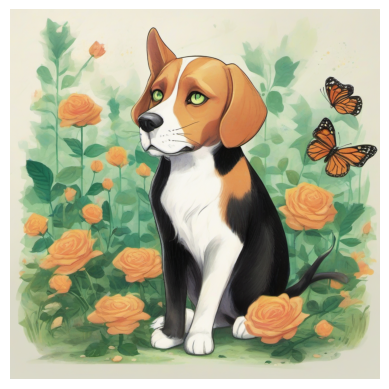

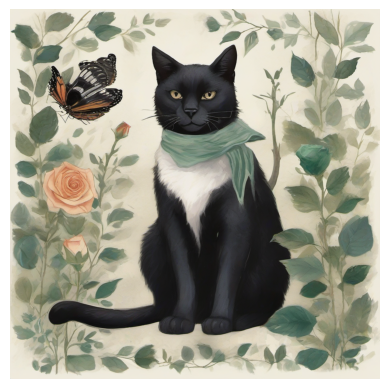

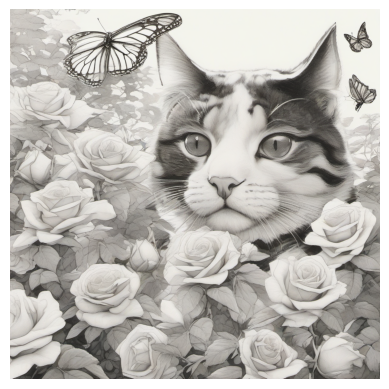

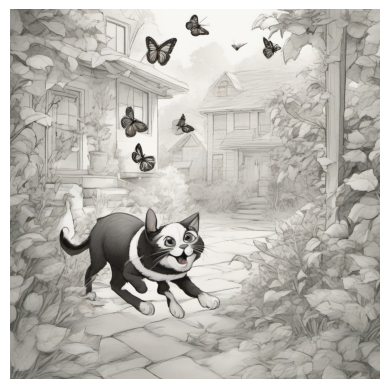

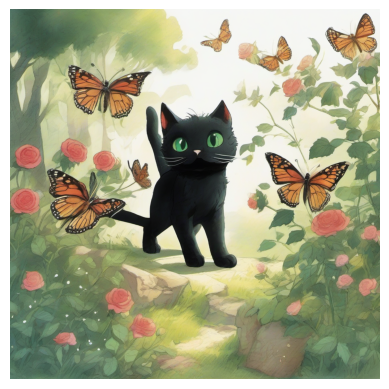

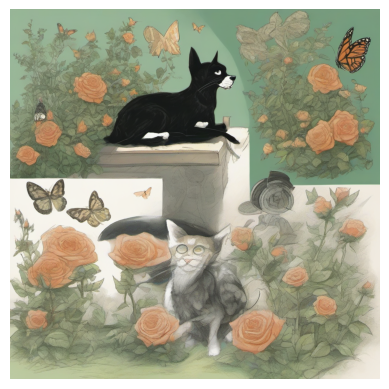

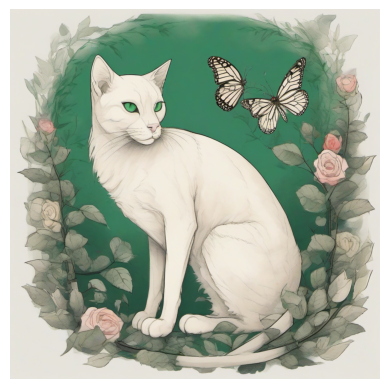

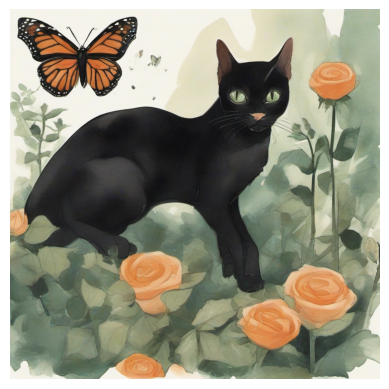

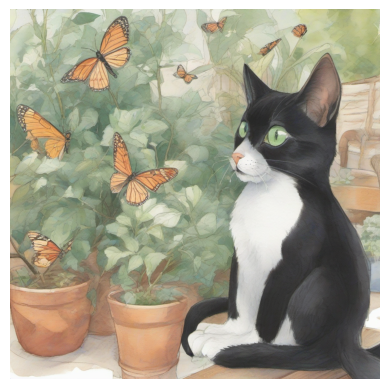

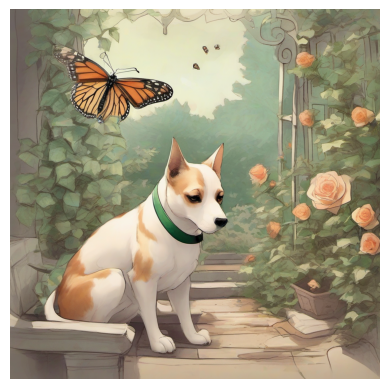

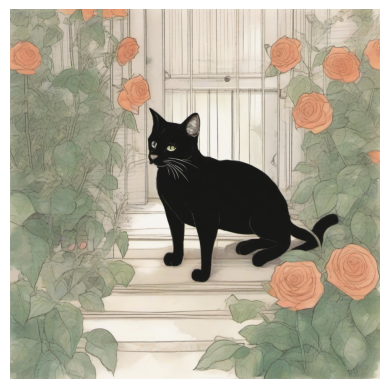

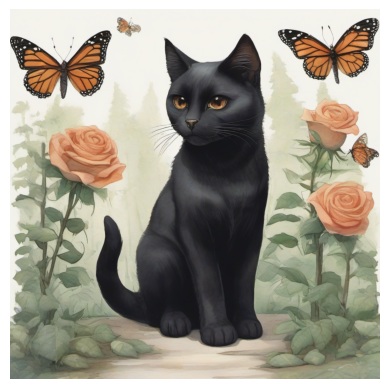

In [17]:
# Initialize client (replace with your token if needed)
client = InferenceClient("stabilityai/stable-diffusion-xl-base-1.0")
for i in range(len(image_generation_prompt_list)):
    prompt = image_generation_prompt_list[i]

    # Generate image
    image = client.text_to_image(
        prompt=prompt,
        height=1024,
        width=1024
    )

    # Save or display
    image.save(f"images/{i}.png")

    # Show inline (in Jupyter/Colab)

    plt.imshow(image)
    plt.axis("off")
    plt.show()


In [1]:
# list_mics.py
import pyaudio

p = pyaudio.PyAudio()

print("Available Audio Input Devices:\n")
for i in range(p.get_device_count()):
    device_info = p.get_device_info_by_index(i)
    if device_info.get('maxInputChannels') > 0:
        print(f"Index: {i}, Name: {device_info.get('name')}")

p.terminate()

Available Audio Input Devices:

Index: 0, Name: Microsoft Sound Mapper - Input
Index: 1, Name: Microphone (DroidCam Audio)
Index: 2, Name: Microphone Array (Realtek(R) Au
Index: 5, Name: Primary Sound Capture Driver
Index: 6, Name: Microphone (DroidCam Audio)
Index: 7, Name: Microphone Array (Realtek(R) Audio)
Index: 11, Name: Microphone (DroidCam Audio)
Index: 12, Name: Microphone Array (Realtek(R) Audio)
Index: 14, Name: Microphone Array 1 (Realtek HD Audio Mic input with SST)
Index: 15, Name: Microphone Array 2 (Realtek HD Audio Mic input with SST)
Index: 16, Name: Microphone Array 3 (Realtek HD Audio Mic input with SST)
Index: 17, Name: Stereo Mix (Realtek HD Audio Stereo input)
Index: 18, Name: Microphone (Realtek HD Audio Mic input)
Index: 21, Name: PC Speaker (Realtek HD Audio output with SST)
Index: 22, Name: MIDI (Wave)
